In [23]:
import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import SkyCoord, CartesianRepresentation
import matplotlib.pyplot as plt
import spiceypy as spice

from light_deflection import delta_kpn, calc_CE, calc_der_E, calc_der_star, calc_CPE, calc_CO, calc_CT
from ephemeris import ephem_kernel, on_sky_velocity

In [25]:
# Kernels
kernel = ['/srv/jupyterhub/shared/data/kernels/jup365.bsp']
spice.furnsh(kernel)

In [26]:
# Occultation parameters
occ_time = Time('2020-12-21 00:46:00', scale='utc')

sun_spkid = '10'
jup_spkid = '599'
gan_spkid = '503'

sun_GM = (const.G * (1 * u.M_sun)).to(u.km**3 / u.s**2)
jup_GM = (const.G * (1.8986e27 * u.kg)).to(u.km**3 / u.s**2)

# Ganymede's orbital (semi-major axis) radius around Jupiter, and Jupiter's
# physical radius (used for the near/far-limb angular limit), both in km.
r_ganymede = (1070400 * u.km)
r_jupiter = 69911 * u.km

In [27]:
# Geocentric positions at the reference epoch

pos_sun, vel_sun = ephem_kernel(time=occ_time, target=sun_spkid, observer='500')
pos_jup, vel_jup = ephem_kernel(time=occ_time, target=jup_spkid, observer='500')
pos_gan, vel_gan = ephem_kernel(time=occ_time, target=gan_spkid, observer='500')

pos_jup = pos_jup.cartesian
pos_sun = pos_sun.cartesian

e_f = SkyCoord(-np.sin(pos_gan.spherical.lon), np.cos(pos_gan.spherical.lon), 0, representation_type='cartesian').cartesian
e_g = SkyCoord(-np.cos(pos_gan.spherical.lon)*np.sin(pos_gan.spherical.lat), -np.sin(pos_gan.spherical.lon)*np.sin(pos_gan.spherical.lat), np.cos(pos_gan.spherical.lat), representation_type='cartesian').cartesian
pos_gan = pos_gan.cartesian

In [28]:
DA_sun = pos_sun.norm()
DA_jup = pos_jup.norm()
DE_gan = pos_gan.norm()
print('Sun', DA_sun.to(u.au))
print('Jup', DA_jup.to(u.au))
print('Gan', DE_gan.to(u.au))

Sun 0.9837447150221438 AU
Jup 5.920317985625541 AU
Gan 5.91593859143273 AU


In [29]:
spice.kclear()

In [30]:
# SG1 star: Gaia DR3 6866303987792105856
pos_star = SkyCoord('20h09m33.4968s -20d35m38.7271s', distance=77.8972*u.pc)
d_sg1 = 77.8972 * u.pc

In [31]:
# Deflection helper, recalculating vectors in the loop

def deflec_vecs(pos_observer, pos_source, pos_massive, gm):
    vec_rso = pos_observer - pos_source
    vec_rao = pos_observer - pos_massive
    vec_ras = pos_source - pos_massive
    return delta_kpn(gm=gm, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

In [32]:
def omt_scan(name, gm_massive, d_star, r_orb, r_planet, thetas, jup_distances_au):

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(jup_distances_au)))
    results = {}

    plt.figure()

    limit_angle = np.arcsin((r_planet / r_orb).to(u.dimensionless_unscaled)).to(u.deg)
    print(f"Angular limit: {limit_angle:.2f}")
    print(f"OMT angle between {180 - limit_angle.value:.2f} deg and {limit_angle.value:.2f} deg")

    lines_styles = {
        6.5: {'linestyle': '-', 'linewidth': 2},
        3.9: {'linestyle': (0, (0.85, 1, 1, 1)), 'linewidth': 2},
    }

    pos_earth = CartesianRepresentation(0 * u.km, 0 * u.km, 0 * u.km)

    for i, dist_au in enumerate(jup_distances_au):
        pos_massive = CartesianRepresentation((dist_au * u.au).to(u.km), 0 * u.km, 0 * u.km)

        separations = []
        corrections = []

        for theta in thetas:
            x_sat = pos_massive.x + r_orb * np.cos(theta)
            y_sat = pos_massive.y + r_orb * np.sin(theta)
            pos_sat = CartesianRepresentation(x_sat, y_sat, 0 * u.km)

            v_earth_gan = pos_sat - pos_earth
            pos_star = pos_sat + v_earth_gan / v_earth_gan.norm() * d_star

            # OMT angle
            vec_OM = pos_earth - pos_massive
            vec_MT = pos_sat - pos_massive
            sep = SkyCoord(vec_OM).separation(SkyCoord(vec_MT))

            delta_k_gan = deflec_vecs(pos_earth, pos_sat, pos_massive, gm_massive)
            delta_k_star = deflec_vecs(pos_earth, pos_star, pos_massive, gm_massive)

            CE = calc_CE(pos_sat.norm(), delta_k_gan, delta_k_star)

            separations.append(sep.to(u.deg).value)
            corrections.append(CE.to(u.km).value)

        results[f'Jupiter: {dist_au} au'] = {
            'separations': separations,
            'corrections': corrections,
            'limit_angle': limit_angle,
        }

        style_graph = lines_styles.get(dist_au, {'linestyle': '-', 'linewidth': 1.5})
        label = f'($D_J={dist_au}$ au)'
        plt.plot(separations, corrections, color=colors[i], label=label, **style_graph)

    plt.axvspan(plt.xlim()[0], limit_angle.value, color='grey', alpha=0.4, zorder=0)
    plt.axvspan(180 - limit_angle.value, plt.xlim()[1], color='grey', alpha=0.4, zorder=0)

    plt.axvline(x=limit_angle.value, color='#d55e00', linestyle='--', linewidth=1.5, label='Near-side limb crossing')
    plt.axvline(x=180 - limit_angle.value, color='#0072b2', linestyle=':', linewidth=2.5, label='Far-side limb crossing')

    plt.xlabel('OMT Angle (deg)', fontsize=12)
    plt.ylabel('Astrometric correction, $(C_E)$ (km)', fontsize=12)
    plt.yscale('log')
    plt.xlim(0, 180)
    plt.title(f'{name}', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', borderaxespad=1.5)
    plt.savefig('OMT_varia.pdf', bbox_inches='tight')
    plt.show()
    return results

Angular limit: 3.74 deg
OMT angle between 176.26 deg and 3.74 deg


/usr/local/lib/python3.13/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.13/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.13/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/l

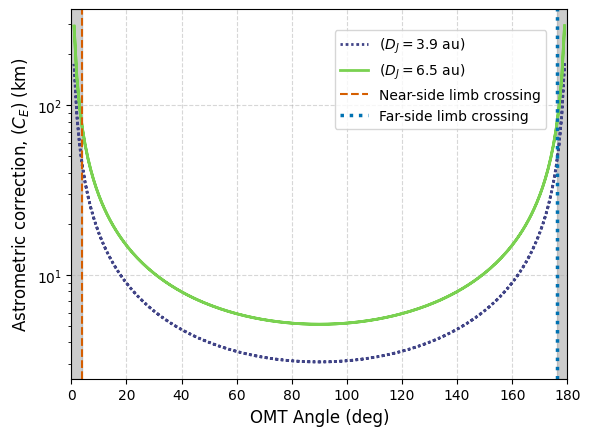

In [33]:
# Plot the graph
thetas = np.linspace(0, 2 * np.pi, 361)
jup_distances_au = [3.9, 6.5]

result = omt_scan("", jup_GM, d_sg1, r_ganymede, r_jupiter, thetas, jup_distances_au)